This notebook runs through elements of the optimized first wedge and the QQ+Sector Dipole dispersion suppressor.

Written by: Inci Karaaslan

Created: 2/22/2026

# Setup

In [145]:
# Important! All of the functions utilized in this notebook unless defined here comes from these two scripts. 
# For more information on the functions, check scan.py and g4beam.py!!
from scan import *
from g4beam import *

import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
from scipy.optimize import differential_evolution
import re

In [2]:
# Make Sure g4bl path is in here -- change the "/home/incik/G4beamline-3.08/bin" with your "G4beamline-3.08/bin" path
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


# Initial distribution

First Wedge Optimization done by Daniel Fu: A Gaussian beam is generated using Mike Syphers' theoretical description of the parameters needed via https://nicadd.niu.edu/~syphers/tutorials/analyzeTrack.html#analyzing-a-distribution.

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [ ]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14312908991573625 mm
beta  = 0.03050738993528868 m
gamma = 49.277007726094396 1/m
alpha = 0.7094454803183923
D     = -0.0018153785582222383 m
D'    = -0.010129811040432882

Twiss parameters for Y
emit  = 0.14759796390442118 mm
beta  = 0.030108562244756106 m
gamma = 49.74969494990426 1/m
alpha = 0.7056144748067608
D     = -0.0010618526181687435 m
D'    = -0.0008609934890434042

Z-emittance:  1.2614805699872884 mm
Z std: 154.01412281614722 mm
p std: 0.9996088130205232 MeV/c
Mean momentum: 100.01064151805367 MeV/c
-----------------------------


In [4]:
write_trackfile(pre_w1, "particles_before_firstwedge.txt")

# First wedge -- Run Optimized Value

In [5]:
post_w1 =  run_g4beam(pre_w1, "G4_FinalCooling_auto.g4bl")
print_all_params(post_w1)

-----------------------------
Twiss parameters for X
emit  = 0.04532444683275656 mm
beta  = 0.035222060938960416 m
gamma = 190.07190944374813 1/m
alpha = -2.386362163882981
D     = 0.019917391890654296 m
D'    = -0.06410542405340892

Twiss parameters for Y
emit  = 0.15304824615933046 mm
beta  = 0.0252331545467193 m
gamma = 57.88018318887292 1/m
alpha = -0.6786012139668296
D     = -0.00032150896853197817 m
D'    = -0.011742459809021995

Z-emittance:  6.421477276117127 mm
Z std: 142.8485139739897 mm
p std: 7.231677899619705 MeV/c
Mean momentum: 88.00297603994014 MeV/c
-----------------------------


In [6]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_after_firstwedge.txt")

In [7]:
# Optimized G4_FinalCooling_auto.g4bl parameters
w1_length = 7.08 #mm
w1_angle = 47.2 #deg
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 24
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 25.0mm


In [8]:
# If particles_after isn't updated with Z = 0, so if we want to use the resulting distribution as the initial distribution
# for each of the files, we must set the particle distribution we get after to have a z of 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [9]:
convertZ("particles_after_firstwedge.txt", "particles_after_firstwedgeupt.txt", set_to=0.0)

Updated file saved as 'particles_after_firstwedgeupt.txt'


# Dispersion correction optimized

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [10]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [11]:
def clean_field_files():
    for f in ["field_cellBSec.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)

In [12]:
# Beta and Dispersion we have from after the wedge:
post_w1 = cut_pz(post_w1)
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))

$\beta_x$: 0.041885034200485734 $\beta_y$: 0.025206172527456515
D_x: 0.02035641802917429 D_y: -0.0005284788706528315


In [ ]:
def beam_size(beta, eps, n_sigma=15):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return n_sigma * sigma

In [19]:
# Height and Width of B field
size_b = max(
    np.percentile(np.abs(post_w1["x"]), 99.9),
    np.percentile(np.abs(post_w1["y"]), 99.9)
    ) * 10.0
print("So the B radius: " + str(size_b) + " mm")

So the B radius: 67.94065720000077 mm


In [153]:
def run_dipole(df, B_field, B_angle, B_radius, B_z, B_thickness=50, B_height=100):
    if os.path.exists("field_cellB.dat"):
        os.remove("field_cellB.dat")
    """Run dipole simulation with given parameters."""
    params = {
        "B1_field": B_field,
        "B1_angle": B_angle,
        "B1_radius": B_radius,
        "B1_z": B_z,
        "B1_z_end": B_z + 2 * (B_radius * B_angle * math.pi/360)+0.1,
        "B1_x_end": B_z - B_thickness * math.sin(B_angle * math.pi/360),
        "B1_thickness": B_thickness,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", params, "G4_FinalCooling_dispsup_B_run.g4bl")
    # Run G4Beamline
    df_out = run_g4beam(df, "G4_FinalCooling_dispsup_B_run.g4bl")

    return df_out

In [154]:
def optimize_dipole_D(x, df_in, beta_x_ref, beta_y_ref,
                      w_disp=100.0, w_beta=1.0, survival_threshold=0.95):
    B_field, B_angle, B_radius, B_z = x
    print(f"TRYING x: {x}")

    result = run_dipole(df_in, B_field, B_angle, B_radius, B_z)
    if result is None or len(result) == 0:
        print("no particles survived, penalize heavily")
        return 1e6

    survival_frac = len(result) / len(df_in)
    if survival_frac < survival_threshold:
        print(f"Survival fraction: {survival_frac:.3f}. Trying sth else..")
        return 1e6 + 1e3 * (survival_threshold - survival_frac)

    # Recenter after bend
    result = result.copy()
    result["x"]  -= np.mean(result["x"])
    result["Px"] -= np.mean(result["Px"])

    x_params_d, y_params_d, _ = calc_all_params(result)
    Dx   = x_params_d[4]
    Dxp  = x_params_d[5]
    beta_x = x_params_d[1]
    beta_y = y_params_d[1]

    disp_penalty = (Dx / 1e-4)**2
    beta_penalty = (max(0, beta_x - 1.0))**2 + (max(0, beta_y - 1.0))**2

    val = w_disp * disp_penalty + w_beta * beta_penalty
    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.6f}, Dxp = {Dxp:.4f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [160]:
def optimize_dipole_Dp(x, df_in, beta_x_ref, beta_y_ref,
                      w_disp=100.0, w_beta=1.0, survival_threshold=0.95):
    B_field, B_angle, B_radius, B_z = x
    print(f"TRYING x: {x}")

    result = run_dipole(df_in, B_field, B_angle, B_radius, B_z)
    if result is None or len(result) == 0:
        print("no particles survived, penalize heavily")
        return 1e6

    survival_frac = len(result) / len(df_in)
    if survival_frac < survival_threshold:
        print(f"Survival fraction: {survival_frac:.3f}. Trying sth else..")
        return 1e6 + 1e3 * (survival_threshold - survival_frac)

    # Recenter after bend
    result = result.copy()
    result["x"]  -= np.mean(result["x"])
    result["Px"] -= np.mean(result["Px"])

    x_params_d, y_params_d, _ = calc_all_params(result)
    Dx   = x_params_d[4]
    Dxp  = x_params_d[5]
    beta_x = x_params_d[1]
    beta_y = y_params_d[1]

    disp_penalty = (Dx / 1e-4)**2 + 100* (Dxp / 1e-2)**2
    beta_penalty = (max(0, beta_x - 1.0))**2 + (max(0, beta_y - 1.0))**2

    val = w_disp * disp_penalty + w_beta * beta_penalty
    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.6f}, Dxp = {Dxp:.4f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [114]:
theta = math.asin(-x0_params[5]) * 180/np.pi
rho = x0_params[4] / (1 - math.cos(theta * np.pi/180))
print(theta, rho)

6.100538411287453 3.5946004233260433


In [155]:
start = time.time()
# Run optimization def: [1.5, 2.0, 1000.0, 1.0]
optim_result = minimize(optimize_dipole_D, [-1.5,  1.37663546e+00,  1.87185672e+03,  1.55732126e+01], args=(post_w1, beta_x_ref, beta_y_ref), method="Nelder-Mead", bounds=((-3.0, 3.0), (1.0, 10.0), (size_b*10, 15000), (0.5, 1000.0)), options=dict(fatol=1e-6))

# Get results
B_field, B_angle, B_radius, B_z = optim_result.x
print(f"Field = {B_field:.2f} T \nAngle = {B_angle:.2f} deg\nRadius = {B_radius:.1f} mm\nSpacing = {B_z:.1f} mm")
print("Time spent:", time.time()-start)

iter value
TRYING x: [-1.50000000e+00  1.37663546e+00  1.87185672e+03  1.55732126e+01]


Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.57500000e+00  1.37663546e+00  1.87185672e+03  1.55732126e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.50000000e+00  1.44546723e+00  1.87185672e+03  1.55732126e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.50000000e+00  1.37663546e+00  1.96544956e+03  1.55732126e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.50000000e+00  1.37663546e+00  1.87185672e+03  1.63518732e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.53750000e+00  1.41105135e+00  1.91865314e+03  1.47945520e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.50937500e+00  1.38523943e+00  1.88355582e+03  1.59625429e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.53750000e+00  1.37663546e+00  1.87185672e+03  1.55732126e+01]
Survival fraction: 0.294. Trying sth else..
TRYING x: [-1.50000000e+00  1.41105135e+00  1.87185672e+03  1.55732126e+01]
Survival fraction: 0.294. Trying sth els

In [152]:
# HMMM : array([-3.00000000e+00,  1.19032267e+00,  2.27473050e+03,  5.00006016e-01])

array([-3.00000000e+00,  1.19032267e+00,  2.27473050e+03,  5.00006016e-01])

In [ ]:
# HMMM : array([-3.00000000e+00,  1.19032267e+00,  2.27473050e+03,  5.00006016e-01])

array([-3.00000000e+00,  1.19032267e+00,  2.27473050e+03,  5.00006016e-01])

In [156]:
opt_params = {
        "B1_field": optim_result.x[0],
        "B1_angle": optim_result.x[1],
        "B1_radius": optim_result.x[2],
        "B1_z": optim_result.x[3],
        "B1_z_end": optim_result.x[3] + 2 * (optim_result.x[2] * optim_result.x[1] * math.pi/360)+0.1,
        "B1_x_end": optim_result.x[3] - 50 * math.sin(optim_result.x[1] * math.pi/360),
        "B1_thickness": 50,
        "B1_height": 100,
    }
if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")
write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", opt_params, "G4_FinalCooling_dispsup_B_opt.g4bl")
df_dip = run_g4beam(post_w1, "G4_FinalCooling_dispsup_B_opt.g4bl")

In [171]:
write_trackfile(df_dip, "particles_after_b.txt")

if os.path.exists("particles_after_bupt.txt"):
    os.remove("particles_after_bupt.txt")
convertZ("particles_after_b.txt",  "particles_after_bupt.txt")

x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)
df_dip_zero = read_trackfile( "particles_after_bupt.txt")

Updated file saved as 'particles_after_bupt.txt'
{'D_x': np.float64(0.008554021452755795), "D'_x": np.float64(-0.3347513865561657), 'D_y': np.float64(-0.0015196091934992024), "D'_y": np.float64(-0.020920094511726845)} Epsilon_z: 5.120388037920065 {'Beta_x': np.float64(1.225322128411862), 'Beta_y': np.float64(0.32886307725190284)}


In [172]:
# Recenter after bend
after_B1 = df_dip_zero.copy()
after_B1["x"]  -= np.mean(after_B1["x"])
after_B1["Px"] -= np.mean(after_B1["Px"])

x_B1, y_B1, _ = calc_all_params(after_B1)
print(f"After B1: Dx={x_B1[4]:.6f}, Dxp={x_B1[5]:.4f}, beta_x={x_B1[1]:.3f}")

After B1: Dx=-0.028741, Dxp=-0.5956, beta_x=1.263


In [166]:
n_sigma_x = beam_size(x_B1[1], x_B1[0])
n_sigma_y = beam_size(y_B1[1], y_B1[0])
print("Determine the Quad Width: " + str(n_sigma_x),"Determine the Quad Height: " + str(n_sigma_y))
# Radius of the quads should be:
radius_q = max(
    np.percentile(np.abs(after_B1["x"]), 99.9),
    np.percentile(np.abs(after_B1["y"]), 99.9)
    ) * 5.0
print("So the quad radius: " + str(radius_q) + " mm")
B_pole_max = 5.0
gradBound = B_pole_max / (radius_q*1e-3)
print(f"Max gradient bound for quads : ({-gradBound}, {gradBound}) ")

Determine the Quad Width: 98.54186448923653 Determine the Quad Height: 103.64277143750039
So the quad radius: 148.4463332825937 mm
Max gradient bound for quads : (-33.68220615110526, 33.68220615110526) 


In [174]:
def run_two_quadrupoles(df, Q1_gradient, Q2_gradient, Drift1_length, Q1_z, Q1_length=100, Q2_length=100, Q1_radius=radius_q, Q2_radius=radius_q, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}",
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}",
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q2.g4bl", params, "G4_FinalCooling_dispsup_Q2_run.g4bl")
    
    # Run this file
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q2_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [175]:
def optimize_qq_drift_safe(x, df, beta_x_ref, beta_y_ref, w_disp=10, w_beta=1000.0):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_gradient, q2_gradient, d1_length, q1_z = x
    print("\nTRYING x =", x)

    try:
        result = run_two_quadrupoles(df, q1_gradient, q2_gradient, d1_length, q1_z)
        # Check where particles are dying
        print(f"x range: {result['x'].min():.1f} to {result['x'].max():.1f} mm")
        print(f"y range: {result['y'].min():.1f} to {result['y'].max():.1f} mm")
        print(f"Pz range: {result['Pz'].min():.1f} to {result['Pz'].max():.1f} MeV/c")
        print(f"Input: {len(df)}, Output: {len(result)}")
    except Exception as e:
        print("EXCEPTION in run_two_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = 3000 #len(df)
    Ns = len(result)

    survival = Ns / N0
    print(f"Particles survived: {Ns}/{N0} → survival={survival:.3f}")

    if survival < 0.95:
        print(f"Survival too low, returning penalty")
        return 1e7 + 1e6 * (0.95 - survival)

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5
    

    Dx = x_params[4]
    Dxp = x_params[5]
    beta_x = x_params[1]
    beta_y = y_params[1]
    ex = x_params[0]
    ey = y_params[0]
    
    eps = 1e-4
    
    disp_penalty =  (np.abs(Dx) / 1e-4)**2 + 10 * (np.abs(Dxp) / 1e-2)**2
    beta_penalty = ((beta_x - beta_x_ref) / beta_x_ref)**2 + ((beta_y - beta_y_ref) / beta_y_ref)**2
    # Log-scaled optics loss
    optics_loss = w_beta * np.log(beta_penalty**2 + eps)
    disp_loss = w_disp * np.log(disp_penalty + eps)

    # Total objective
    val = optics_loss + disp_loss

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, Dxp={Dxp:.6f}, beta_penalty={beta_penalty:.6f}, emit={ex:.6f}")
    return val

In [176]:
def optimize_qqb_drift_safe(x, df, beta_x_ref, beta_y_ref, w_disp=10, w_beta=1000.0, survival_threshold=0.95):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_grad, q2_grad, d1_length, q1_z,   \
    B2_field, B2_angle, B2_radius, B2_z  = x
    print("\nTRYING x =", x)

    try:
        after_qq = run_two_quadrupoles(
            after_B1, q1_grad, q2_grad, d1_length, q1_z,
            Q1_radius=radius_q, Q2_radius=radius_q
        )
    except Exception as e:
        print(f"QQ exception: {e}")
        return 1e6

    if after_qq is None or len(after_qq) < 10:
        print("QQ: no particles")
        return 1e6

    survival_qq = len(after_qq) / len(after_B1)
    if survival_qq < survival_threshold:
        print(f"QQ survival: {survival_qq:.3f}")
        return 1e6 + 1e3 * (survival_threshold - survival_qq)

    x_qq, y_qq, _ = calc_all_params(after_qq)
    print(f"After QQ: Dx={x_qq[4]:.6f}, Dxp={x_qq[5]:.4f}, beta_x={x_qq[1]:.3f}")

    # QQ should not blow up beta or emittance
    # if beta is huge the beam is diverging and B2 can't help
    if x_qq[1] > 10.0 or y_qq[1] > 10.0:
        print(f"QQ beta blowup: beta_x={x_qq[1]:.2f}, beta_y={y_qq[1]:.2f}")
        return 1e6

    # QQ should not blow up emittance — indicates particles being lost or phase space distorted
    if x_qq[0] > 5 * x_B1[0] or y_qq[0] > 5 * y_B1[0]:
        print(f"QQ emittance blowup")
        return 1e6

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, Dxp={Dxp:.6f}, beta_penalty={beta_penalty:.6f}, emit={ex:.6f}")
    # --- B2 aperture radius sized from actual QQ output beam ---
    # (B2 is a dipole so no aperture arg, but print for info)
    b2_size = max(
        np.percentile(np.abs(after_qq["x"]), 99.9),
        np.percentile(np.abs(after_qq["y"]), 99.9)
    )
    print(f"QQ radius used: {radius_q:.1f} mm, beam size into B2: {b2_size:.1f} mm")

    # --- Stage 3: Second dipole ---
    after_B2 = run_dipole(after_qq, B2_field, B2_angle, B2_radius, B2_z)
    if after_B2 is None or len(after_B2) == 0:
        print("B2: no particles")
        return 1e6

    survival_B2 = len(after_B2) / (after_qq)
    if survival_B2 < survival_threshold:
        print(f"B2 survival: {survival_B2:.3f}")
        return 1e6 + 1e3 * (survival_threshold - survival_B2)

    # Recenter after second bend
    after_B2 = after_B2.copy()
    after_B2["x"]  -= np.mean(after_B2["x"])
    after_B2["Px"] -= np.mean(after_B2["Px"])

    # --- Measure final output ---
    x_params, y_params, _ = calc_all_params(after_B2)
    Dx    = x_params[4]
    Dxp   = x_params[5]
    beta_x = x_params[1]
    beta_y = y_params[1]

    disp_penalty = (Dx  / 1e-4)**2 + (Dxp / 1e-2)**2
    beta_penalty = (max(0, beta_x - 1.0))**2 + (max(0, beta_y - 1.0))**2

    val = w_disp * disp_penalty + w_beta * beta_penalty
    print(f"OBJECTIVE = {val:.3f}, Dx={Dx:.6f}, Dxp={Dxp:.4f}, "
          f"beta_x={beta_x:.3f}, beta_y={beta_y:.3f}, surv={survival_B2:.3f}")

In [ ]:
x0 = [5, -5, 20, L_centerline*2, 1.5, 2, 400, 2]#[ -9.00758863, 11.56562394, 19.697143, L_centerline*2] #[-9.00758863, 11.56562394,  40.41906277, L_centerline] # [ -9.00758863, 11.56562394, 19.697143, L_centerline]
# Physical bounds
bounds = np.array([
    [-gradBound, gradBound],      # Q1_gradient
    [-gradBound, gradBound],    # Q2_gradient
    [10, 3000],    # Drift1_length
    [L_centerline, L_centerline*100],
    [-3.0,   3.0],    # B2_field
    [1.0,   25.0],    # B2_angle
    [200.0, 2000.0],  # B2_radius
    [1.0,   10.0],    # B2_z ← same
])
res = scipy.optimize.minimize(
    optimize_qqb_drift_safe, x0,
    args=(after_B1, 0.040, 0.025),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
print("Optimal parameters:", res.x)


TRYING x = [  5.   -5.   20.   50.    1.5   2.  400.    2. ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 100.000000000000
Q1_length = 100.000000000000
Q1_gradient = 5.000000000000
radius_q1 = 148.446333282594
radius_q2 = 148.446333282594
thickness = 5.000000000000
Q1_end = 150.000000000000
Q2_length = 100.000000000000
Q2_gradient = -5.000000000000
Drift1_length = 20.000000000000
Drift1_z = 160.000000000000
Drift1_width = 296.892666565187
Drift1_height = 296.892666565187
D1_end = 170.000000000000
Q2_z = 220.000000000000
Q2_end = 270.000000000000
After QQ: Dx=-0.178381, Dxp=-0.6999, beta_x=11.655
QQ beta blowup: beta_x=11.66, beta_y=6.71

TRYING x = [  5.25  -5.    20.    50.     1.5    2.   400.     2.  ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 100.000000000000
Q1_length = 100.000000000000
Q1_gradient = 5.250000000000
radius_q1 = 148.446333282594
radius_q2 = 148.446333282594
thickness = 5.000000000000
Q1_end = 150.000000000000
Q2_length = 100.000000000000
Q2_gradient = -5.000000000000
Drift1_length = 

In [170]:
x0 = [5, -5, 20, L_centerline*2]#[ -9.00758863, 11.56562394, 19.697143, L_centerline*2] #[-9.00758863, 11.56562394,  40.41906277, L_centerline] # [ -9.00758863, 11.56562394, 19.697143, L_centerline]
# Physical bounds
bounds = np.array([
    [-gradBound, gradBound],      # Q1_gradient
    [-gradBound, gradBound],    # Q2_gradient
    [10, 3000],    # Drift1_length
    [L_centerline, L_centerline*100]
])
res = scipy.optimize.minimize(
    optimize_qq_drift_safe, x0,
    args=(df_dip_zero, 0.040, 0.025),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
print("Optimal parameters:", res.x)


TRYING x = [  5.   -5.   20.   50.    1.5   2.  400.    2. ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 100.000000000000
Q1_length = 100.000000000000
Q1_gradient = 5.000000000000
radius_q1 = 148.446333282594
radius_q2 = 148.446333282594
thickness = 5.000000000000
Q1_end = 150.000000000000
Q2_length = 100.000000000000
Q2_gradient = -5.000000000000
Drift1_length = 20.000000000000
Drift1_z = 160.000000000000
Drift1_width = 296.892666565187
Drift1_height = 296.892666565187
D1_end = 170.000000000000
Q2_z = 220.000000000000
Q2_end = 270.000000000000


After QQ: Dx=-0.177769, Dxp=-0.6976, beta_x=11.699
QQ beta blowup: beta_x=11.70, beta_y=6.71

TRYING x = [  5.25  -5.    20.    50.     1.5    2.   400.     2.  ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 100.000000000000
Q1_length = 100.000000000000
Q1_gradient = 5.250000000000
radius_q1 = 148.446333282594
radius_q2 = 148.446333282594
thickness = 5.000000000000
Q1_end = 150.000000000000
Q2_length = 100.000000000000
Q2_gradient = -5.000000000000
Drift1_length = 20.000000000000
Drift1_z = 160.000000000000
Drift1_width = 296.892666565187
Drift1_height = 296.892666565187
D1_end = 170.000000000000
Q2_z = 220.000000000000
Q2_end = 270.000000000000
After QQ: Dx=-0.176428, Dxp=-0.6885, beta_x=11.857
QQ beta blowup: beta_x=11.86, beta_y=6.79

TRYING x = [  5.    -5.25  20.    50.     1.5    2.   400.     2.  ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 100.000000000000
Q1_length = 100.000000000000
Q1_gradient = 5.000000000000
radius_q1 = 148.446333282594
radius_q2 = 148.446333282594
thickness = 5.000000000000


KeyboardInterrupt: 

In [45]:
df_opt_q = run_two_quadrupoles(df_dip_zero, Q1_gradient=res.x[0], Q2_gradient=res.x[1], Drift1_length=res.x[2], Q1_z=res.x[3])
print(df_opt_q)
write_trackfile(df_opt_q, "particles_after_q2.txt")

PARAMS PASSED TO TEMPLATE:
Q1_z = 148.019973311265
Q1_length = 100.000000000000
Q1_gradient = 12.510352191335
radius_q1 = 399.669004000002
radius_q2 = 399.669004000002
thickness = 5.000000000000
Q1_end = 198.019973311265
Q2_length = 100.000000000000
Q2_gradient = 12.510352191335
Drift1_length = 10.000000000000
Drift1_z = 203.019973311265
Drift1_width = 799.338008000004
Drift1_height = 799.338008000004
D1_end = 208.019973311265
Q2_z = 258.019973311265
Q2_end = 308.019973311265


            x        y       z        Px       Py       Pz         t  PDGid  \
0     95.9078 -89.5616  308.02 -43.22820 -42.2077  47.5848  0.572578    -13   
1     82.2168 -24.1665  308.02 -23.00100 -13.8674  84.6515  2.076340    -13   
2     84.7970 -53.1903  308.02 -25.53720 -28.9997  78.5002  1.732230    -13   
3     54.6765  51.0194  308.02 -10.82800  28.6527  87.7777  1.520900    -13   
4     90.8892  49.8542  308.02 -30.80500  26.4779  72.4030  2.526260    -13   
...       ...      ...     ...       ...      ...      ...       ...    ...   
9908  85.4539  37.7424  308.02 -23.69300  21.4957  86.2598  2.329620    -13   
9909  68.2723 -84.5850  308.02 -16.32070 -46.7374  78.9981  2.077930    -13   
9910  52.7491  50.3007  308.02  -9.30415  29.4331  91.6416  1.427150    -13   
9911  75.9730  47.5419  308.02 -25.74280  24.0789  68.5943  1.944910    -13   
9912  82.0004  94.9169  308.02 -26.46870  48.7231  62.8139  2.392670    -13   

      EventID  TrackID  ...  ProperTime  PathLength

In [47]:
x_params_q, y_params_q, z_emit_q = calc_all_params(df_opt_q)
print("Dx, Dy =", x_params_q[4], y_params_q[4])
b_dict = {"Beta_x" : x_params_q[1], "Beta_y" : y_params_q[1]}
print(b_dict)
with open("particles_after_q2.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 12000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dy = -0.0015894709250844038 -0.012204212768264265
{'Beta_x': np.float64(0.41393698717581384), 'Beta_y': np.float64(1.0339925209085765)}
9913
Transmission =  82.60833333333333


In [48]:
if os.path.exists("particles_after_q2upt.txt"):
    os.remove("particles_after_q2upt.txt")
convertZ("particles_after_q2.txt", "particles_after_q2upt.txt", set_to=0.0)
df_opt_q_zero = read_trackfile("particles_after_q2upt.txt")

Updated file saved as 'particles_after_q2upt.txt'


In [ ]:
# Height and Width of B field
size_b2 = max(
    np.percentile(np.abs(df_dip["x"]), 99.9),
    np.percentile(np.abs(df_dip["y"]), 99.9)
    ) * 10.0
print("So the B radius: " + str(size_b2) + " mm")
start = time.time()
# Run optimization def: [1.5, 2.0, 1000.0, 1.0]
optim_result2 = minimize(optimize_dipole_Dp, [2.5,  1.37663546e+00,  1.87185672e+03,  1.55732126e+01], args=(df_dip_zero, b_dict_dip["Beta_x"], b_dict_dip["Beta_y"]), method="Nelder-Mead", bounds=((-3.0, 3.0), (1.0, 10.0), (size_b2, 15000), (0.5, 1000.0)), options=dict(fatol=1e-6))

# Get results
B_field2, B_angle2, B_radius2, B_z2 = optim_result2.x
print(f"Field = {B_field2:.2f} T \nAngle = {B_angle2:.2f} deg\nRadius = {B_radius2:.1f} mm\nSpacing = {B_z2:.1f} mm")
print("Time spent:", time.time()-start)

Chromaticity proxy (slope of beta vs delta):
dβx/dδ ≈ 1.6135
dβy/dδ ≈ -0.0844
Quadratic term βx: 0.15846147668647154


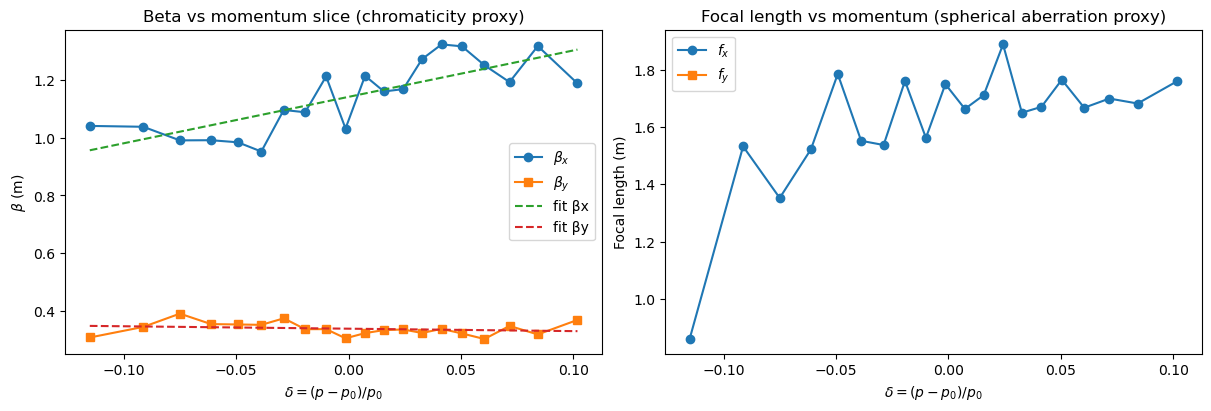

In [54]:
def tune_vs_momentum(df, n_slices=20):
    p = p_total(df)
    p_mean = np.mean(p)
    
    # slice by momentum
    p_edges = np.percentile(p, np.linspace(0, 100, n_slices+1))
    
    betas_x, betas_y, deltas = [], [], []
    for i in range(n_slices):
        mask = (p >= p_edges[i]) & (p < p_edges[i+1])
        slice_df = df[mask]
        if len(slice_df) < 50:
            continue
        x_params, y_params, _ = calc_all_params(slice_df)
        betas_x.append(x_params[1])
        betas_y.append(y_params[1])
        deltas.append((np.mean(p[mask]) - p_mean) / p_mean)
    
    return np.array(deltas), np.array(betas_x), np.array(betas_y)


def focal_length_vs_momentum(df_before, df_after, n_slices=20):
    """
    Focal length from x' = -x/f  →  f = -<x> / <x'>
    computed per momentum slice
    """
    p_before = p_total(df_before)
    p_after  = p_total(df_after)
    p_mean   = np.mean(p_before)
    
    # match particles by EventID
    df_before = df_before.set_index("EventID")
    df_after  = df_after.set_index("EventID")
    common    = df_before.index.intersection(df_after.index)
    db = df_before.loc[common]
    da = df_after.loc[common]
    
    p_edges = np.percentile(p_total(db), np.linspace(0, 100, n_slices+1))
    p_vals  = p_total(db)
    
    focal_x, focal_y, deltas = [], [], []
    for i in range(n_slices):
        mask = (p_vals >= p_edges[i]) & (p_vals < p_edges[i+1])
        if mask.sum() < 50:
            continue
        
        x_in  = db["x"][mask].values
        xp_in = (db["Px"] / p_total(db))[mask].values
        x_out = da["x"][mask].values
        xp_out = (da["Px"] / p_total(da))[mask].values
        
        y_in  = db["y"][mask].values
        yp_in = (db["Py"] / p_total(db))[mask].values
        yp_out = (da["Py"] / p_total(da))[mask].values
        
        # f = -<x_in> / <delta_xp>  where delta_xp = xp_out - xp_in
        delta_xp = xp_out - xp_in
        delta_yp = yp_out - yp_in

        # robust linear fit: delta_xp = (-1/f) * x_in
        if len(x_in) > 10:
            coef = np.polyfit(x_in, delta_xp, 1)   # slope, intercept
            slope = coef[0]
            fx = -1 / slope if np.abs(slope) > 1e-6 else np.nan
        else:
            fx = np.nan
        if len(y_in) > 10:
            coef_y = np.polyfit(y_in, delta_yp, 1)
            slope_y = coef_y[0]
            fy = -1 / slope_y if np.abs(slope_y) > 1e-6 else np.nan
        else:
            fy = np.nan
        
        focal_x.append(fx)
        focal_y.append(fy)
        deltas.append((np.mean(p_vals[mask]) - p_mean) / p_mean)
    
    return np.array(deltas), np.array(focal_x), np.array(focal_y)


# --- plot ---
# for tune shift you need df after the QQ
deltas, bx, by = tune_vs_momentum(df_dip)

# Linear fit: beta vs momentum (chromaticity proxy)
coef_x = np.polyfit(deltas, bx, 1)
coef_y = np.polyfit(deltas, by, 1)

print("Chromaticity proxy (slope of beta vs delta):")
print(f"dβx/dδ ≈ {coef_x[0]:.4f}")
print(f"dβy/dδ ≈ {coef_y[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

axes[0].plot(deltas, bx, "o-", label=r"$\beta_x$")
axes[0].plot(deltas, by, "s-", label=r"$\beta_y$")
axes[0].set_xlabel(r"$\delta = (p - p_0)/p_0$")
axes[0].set_ylabel(r"$\beta$ (m)")
axes[0].set_title("Beta vs momentum slice (chromaticity proxy)")
coef2_x = np.polyfit(deltas, bx, 2)
print("Quadratic term βx:", coef2_x[0])
# fitted lines
delta_fit = np.linspace(min(deltas), max(deltas), 100)

axes[0].plot(delta_fit, np.polyval(coef_x, delta_fit), "--", label="fit βx")
axes[0].plot(delta_fit, np.polyval(coef_y, delta_fit), "--", label="fit βy")

axes[0].legend()
# for focal length you need df before AND after the QQ
deltas_f, fx, fy = focal_length_vs_momentum(post_w1, df_dip)

axes[1].plot(deltas_f, fx/1000, "o-", label=r"$f_x$")  # mm to m
axes[1].plot(deltas_f, fy/1000, "s-", label=r"$f_y$")
axes[1].set_xlabel(r"$\delta = (p - p_0)/p_0$")
axes[1].set_ylabel("Focal length (m)")
axes[1].set_title("Focal length vs momentum (spherical aberration proxy)")
axes[1].legend()

plt.show()

[[  0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.5   0.    0.    0. ]
 [  0.    0.    1.    0.    0.    0. ]
 ...
 [  0.    0.  498.5   0.    0.    0. ]
 [  0.    0.  499.    0.    0.    0. ]
 [  0.    0.  499.5   0.    0.    0. ]]
[('COLORS', 100.0)]


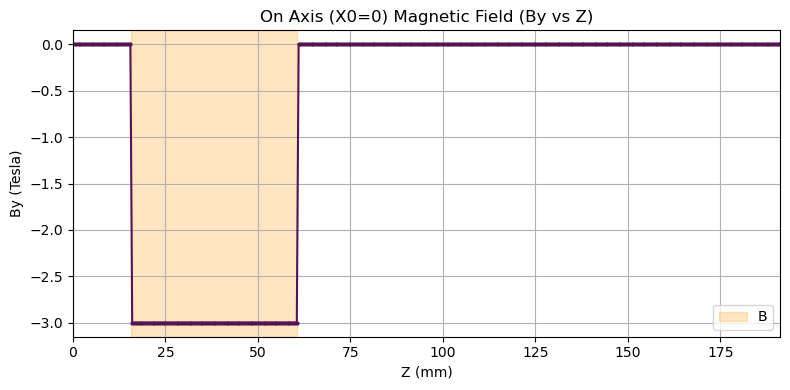

In [55]:
def fieldEvolution():
    """ 
    Evolution of the magnetic field across elements, plotted. 
    
    """
    # Load file, skipping comment lines
    with open("field_cellB.dat") as f:
        lines = f.readlines()[4:]
    
    data = np.array([[float(x) for x in line.split()] for line in lines])
    print(data)
    
    # If the file has columns: x y z Bx By Bz
    # then we can extract:
    z = data[:, 2]
    by = data[:, 4]
    
    
    # Draw shaded regions for magnets
    # Read your g4bl file
    with open("G4_FinalCooling_dispsup_B_opt.g4bl") as f:
        text = f.read()

    # Extract magnets (dipoles, quads, drifts, etc.)
    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = re.findall(pattern, text)
    params = [(k, float(v)) for k, v in entries]
    print(params)
    magnet_colors = {
            "B":     "#FFAA33",   # warm orange
        }

    regions = []
    length = optim_result.x[3] + 2 * (optim_result.x[2] * optim_result.x[1] * math.pi/360)+0.1
    z1 = optim_result.x[3]
    z2 = length
    regions.append((z1, z2, "#FFAA33", "B"))

    plt.figure(figsize=(8, 4))
    for z1, z2, color, label in regions:
        if z1 is not None and z2 is not None:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)
    
    plt.plot(z, by, '-o', color="#541352FF", markersize=2)
    plt.xlim(0.0, (730.1 * 10 *math.pi/360) *3)
    plt.xlabel("Z (mm)")
    plt.ylabel("By (Tesla)")
    plt.title("On Axis (X0=0) Magnetic Field (By vs Z)")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig("Bfields.png")

fieldEvolution()

In [56]:
import re

def parse_magnets_from_g4bl(filename):

    magnet_colors = {
        "Q1": "#6699FF",
        "Drift1": "#BBBBBB",
        "Q2": "#6699FF",
        "B1": "#FFAA33"
    }

    regions = []

    with open(filename) as f:
        text = f.read()

    # ----------------------------
    # Find quadrupoles
    # ----------------------------
    quad_pattern = r"genericquad\s+(\w+).*?fieldLength\s*=\s*([-+]?\d*\.?\d+)"
    quads = re.findall(quad_pattern, text, re.DOTALL)

    # ----------------------------
    # Find dipoles (angle * radius)
    # ----------------------------
    dipole_pattern = (
        r"genericsectorbend\s+(\w+).*?"
        r"angle\s*=\s*([-+]?\d*\.?\d+).*?"
        r"fieldCenterRadius\s*=\s*([-+]?\d*\.?\d+)"
    )
    dipoles = re.findall(dipole_pattern, text, re.DOTALL)

    # Build length dictionary
    magnet_lengths = {}

    for name, length in quads:
        magnet_lengths[name] = float(length)
        
    for name, angle, radius in dipoles:
        magnet_lengths[name] = float(math.radians(float(angle))) * float(radius)

    # ----------------------------
    # Find placements
    # ----------------------------
    place_pattern = r"place\s+(\w+)\s+z\s*=\s*([-+]?\d*\.?\d+)"
    placements = re.findall(place_pattern, text)

    magnet_positions = {name: float(z) for name, z in placements}

    # ----------------------------
    # Build regions
    # ----------------------------
    for name in magnet_positions:
        if name in magnet_lengths and name in magnet_colors:

            pos = magnet_positions[name]
            length = magnet_lengths[name]

            if name.startswith("B"):   # dipole
                z1 = pos
                z2 = pos + length
            else:                      # quad
                z1 = pos - length/2
                z2 = pos + length/2

            regions.append((z1, z2, magnet_colors[name], name))

    return regions

In [57]:
write_trackfile(post_w1, "particles_after_firstwedge.txt")
write_trackfile(df_opt_q, "particles_after_q2.txt")
write_trackfile(df_dip, "particles_after_b.txt")

In [58]:
def twissPlot(z_positions, emit_x, emit_y, emit_z,
              beta_x, beta_y, alpha_x, alpha_y,
              D_x, Dp_x, D_y, Dp_y,
              regions,
              output_folder="./dispsup_plots"):

    os.makedirs(output_folder, exist_ok=True)

    # Convert to arrays (NO sorting — assume correct order)
    z_positions = np.array(z_positions)

    emit_x = np.array(emit_x)
    emit_y = np.array(emit_y)
    emit_z = np.array(emit_z)

    beta_x = np.array(beta_x)
    beta_y = np.array(beta_y)

    alpha_x = np.array(alpha_x)
    alpha_y = np.array(alpha_y)

    D_x = np.array(D_x)
    Dp_x = np.array(Dp_x)
    D_y = np.array(D_y)
    Dp_y = np.array(Dp_y)

    # -------------------------------------------------
    # Plot helper
    # -------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7, 5))

        # Magnet regions
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # Twiss curves
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # Remove duplicate legend entries
        handles, labels_ = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()

    # -------------------------------------------------
    # Generate plots
    # -------------------------------------------------
    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
              "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
              "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
              "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
              "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
              "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")

files = [
    "particles_before_firstwedge.txt",
    "particles_after_b.txt",
    "vd_Q1_dispsup.txt",
    "vd_D1_dispsup.txt",
    "particles_after_q2.txt"
]

z_local_list = []
twiss_data = []

# Read data
for f in files:
    df1 = read_trackfile(f)

    z_local_list.append(df1["z"].iloc[0])

    x_params1, y_params1, z_emit1 = calc_all_params(df1)
    twiss_data.append((x_params1, y_params1, z_emit1))

# -------------------------------------------------
# ✅ Correct global z positions (monotonic)
# -------------------------------------------------
z_positions = [z_local_list[0]]

for i in range(1, len(z_local_list)):
    z_positions.append(z_positions[-1] + z_local_list[i])

# -------------------------------------------------
# Unpack Twiss parameters
# -------------------------------------------------
emit_x, emit_y, emit_z = [], [], []
beta_x, beta_y = [], []
alpha_x, alpha_y = [], []
D_x, Dp_x, D_y, Dp_y = [], [], [], []

for x_params1, y_params1, z_emit1 in twiss_data:
    ex, bx, gx, ax, Dx, Dxp = x_params1
    ey, by, gy, ay, Dy, Dyp = y_params1

    emit_x.append(ex)
    emit_y.append(ey)
    emit_z.append(z_emit1)

    beta_x.append(bx)
    beta_y.append(by)

    alpha_x.append(ax)
    alpha_y.append(ay)

    D_x.append(Dx)
    Dp_x.append(Dxp)
    D_y.append(Dy)
    Dp_y.append(Dyp)

# Load B section
regions_b = parse_magnets_from_g4bl("G4_FinalCooling_dispsup_B_run.g4bl")

# Find end of B
end_b = max(z2 for (_, z2, _, _) in regions_b)

# Load Q2 section and shift it AFTER B
regions_q2_raw = parse_magnets_from_g4bl("G4_FinalCooling_dispsup_Q2_run.g4bl")

regions_q2 = []
for z1, z2, color, name in regions_q2_raw:
    regions_q2.append((z1 + end_b,
                       z2 + end_b,
                       color,
                       name))

# Combine in correct order
regions = regions_b + regions_q2
twissPlot(z_positions,
          emit_x, emit_y, emit_z,
          beta_x, beta_y,
          alpha_x, alpha_y,
          D_x, Dp_x, D_y, Dp_y,
          regions)

All plots saved in './dispsup_plots'


In [59]:
with open("particles_after_b.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 12000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

10195
84.95833333333333


In [143]:
print_all_params(df_dip_zero)

-----------------------------
Twiss parameters for X
emit  = 0.055167554072696134 mm
beta  = 0.7045779555996795 m
gamma = 147.3728548451381 1/m
alpha = -10.140792117861194
D     = 6.536903411138822e-07 m
D'    = -0.592657217938597

Twiss parameters for Y
emit  = 0.1486659007663827 mm
beta  = 0.24079188675655386 m
gamma = 56.64217120456551 1/m
alpha = -3.555133650699376
D     = -0.0012895481357399548 m
D'    = -0.02092014151960844

Z-emittance:  6.961086566956888 mm
Z std: 143.7857067554994 mm
p std: 5.211757386561572 MeV/c
Mean momentum: 88.34174408917474 MeV/c
-----------------------------


In [147]:
def remove_rel_dispersion(df, axis=1):
    """Simulates distribution after dispersion is removed"""
    df = df.copy(deep=True)
    total_momentum = p_total(df)  # MeV/c
    mean_total_momentum = np.mean(total_momentum)
    delta = (total_momentum - mean_total_momentum) / mean_total_momentum

    x_params, y_params, _ = calc_all_params(df)
    _, _, _, _, xD, xDp = x_params
    _, _, _, _, yD, yDp = y_params
    if axis == 1: # ONLY get rid of y dispersion
        df["y"] = df["y"] - yD * delta * 1000
        df["Py"] = df["Py"] - yDp * delta * total_momentum
    
    elif axis == 0: # ONLY get rid of x dispersion
        df["x"] = df["x"] - xD * delta * 1000
        df["Px"] = df["Px"] - xDp * delta * total_momentum
    return df

In [150]:
df_dip_zero_red = remove_rel_dispersion(df_dip_zero)

In [144]:
write_trackfile(df_dip_zero, "trythis.txt")
write_trackfile(df_dip, "trythisnonz.txt")

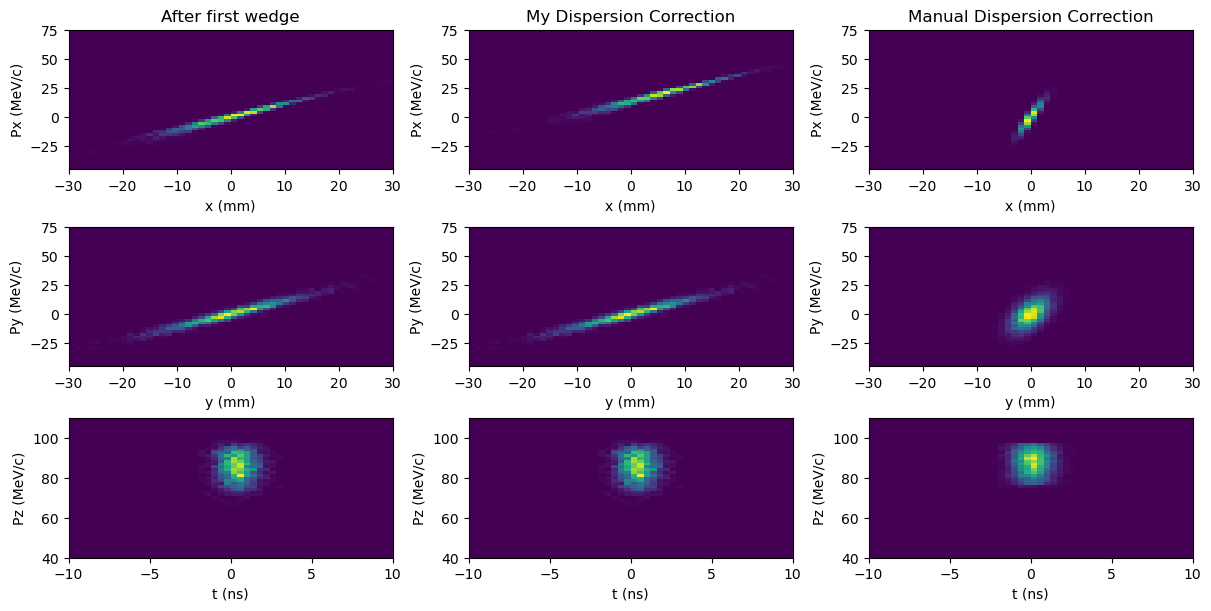

In [173]:
# a more reasonable size
PLOT_TARGETS = [after_B1, df_dip_zero, remove_dispersion(post_w1)]
PLOT_TITLES = ["After first wedge", "My Dispersion Correction", "Manual Dispersion Correction"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-30, 30], [-45, 75]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(12, 6)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

# Drift Channel

In [100]:
n_sigma_x_drift = beam_size(x_params_dip[1], x_params_dip[0])
n_sigma_y_drift = beam_size(y_params_dip[1], y_params_dip[0])
print("Determine the Quad Width: " + str(n_sigma_x_drift),"Determine the Quad Height: " + str(n_sigma_y_drift))
radius_q = max(n_sigma_x_drift, n_sigma_y_drift)
print("Quad Radius needs to be at least: ", radius_q)

Determine the Quad Width: 254.96220129097256 Determine the Quad Height: 262.7206933293358
Quad Radius needs to be at least:  262.7206933293358


In [135]:
write_input_from_template("G4_QuadChannel.g4bl", {"radius_q": radius_q}, "G4_QuadChannel_run.g4bl")

In [153]:
with open("madXDriftChannel/experiment.madx") as f:
    madx_template = f.read()

avg_mom = np.average(p_total(df_dip)) *1e-3
madx_input = madx_template.format(avg_mom=avg_mom, beta_x=x_params_dip[1], beta_y=y_params_dip[1], alpha_x=x_params_dip[3], alpha_y=y_params_dip[3],D_x=D_dict_dip["D_x"], Dp_x=D_dict_dip["D'_x"], D_y=D_dict_dip["D_y"], Dp_y=D_dict_dip["D'_y"])

with open("madXDriftChannel/run.madx", "w") as f:
    f.write(madx_input)

In [154]:
subprocess.run(["madx", "madXDriftChannel/run.madx"], check=True)


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Linux)       +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.03.02 10:44:06      +
  ++++++++++++++++++++++++++++++++++++++++++++
BEAM, particle=POSMUON, PC=0.08867773923236165;

b_start: beta0, betx=0.23484239968359552, bety=1.0297716634079053, alfx=0.8173711459179888, alfy=-6.6273639026127285, dx=4.5849830257607524e-08, dpx=-0.04557222448990703, dy=-0.008338933297010106,  dpy=-0.06175483057866619;

!

!b_goal: beta0,  betx=0.0442, bety=0.0261;



!Starting guess from Ryan

k_qf1= 19;

k_qd1=-19;

FODO: sequence, l=1.1;

    MF0: marker, at=0;

    QF1h: Quadrupole, K1=k_qf1, L=0.075, AT=0.0375;

    QD1h: Quadrupole, K1=k_qd1, L=0.075, AT=0.5125;

    MD: Marker, AT=0.55;

    QD1h: QD1h, AT=0.5875;

    QF1h: QF1h, AT=1.0625;

    MF1: Marker, at=1.1;

endsequence;



!use, sequence=fodo;

!select,flag=twiss,clear;

!twiss, file="ma

CompletedProcess(args=['madx', 'madXDriftChannel/run.madx'], returncode=0)

In [155]:
def read_tfs(filename):
    with open(filename) as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith("*"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("No header line (*) found in TFS file")

    # Extract column names (remove leading '*')
    columns = lines[header_idx].strip().split()[1:]

    # Data starts 2 lines below header
    data_start = header_idx + 2

    data = []
    for line in lines[data_start:]:
        if line.startswith("@") or line.startswith("$") or line.strip() == "":
            continue
        data.append(line.split())

    df = pd.DataFrame(data, columns=columns)
    return df

# ----------------------------
# Load whole lattice
# ----------------------------
df_drift = read_tfs("madXDriftChannel/whole.tfs")

# Clean up the file keys
df_drift["KEYWORD"] = (
    df_drift["KEYWORD"]
    .str.strip()           # remove whitespace
    .str.replace('"', '')  # remove quotes
)

df_drift["NAME"] = (
    df_drift["NAME"]
    .str.strip()
    .str.replace('"', '')
)

# convert numeric columns
for col in ["S", "L", "K1L"]:
    df_drift[col] = pd.to_numeric(df_drift[col], errors="coerce")

# Convert Quads -- Keep only Quads btw
quads = df_drift[df_drift["KEYWORD"] == "QUADRUPOLE"].copy()

# Compute gradient
quads["K1"] = quads["K1L"] / quads["L"]

Brho = 3.3356 * avg_mom
quads["gradient"] = quads["K1"] * Brho

# Convert units
quads["z_mm"] = (quads["S"] - quads["L"]/2) * 1000.0
quads["length_mm"] = quads["L"] * 1000.0

In [156]:
quads["gradient"]

2      -5.377255
4       5.524701
6      -4.077421
8       4.278042
10      5.620076
12      5.620076
14     -5.620076
16     -5.620076
18      5.620076
20      5.620076
22     -5.620076
24     -5.620076
26      5.620076
28      5.620076
30     -5.620076
32     -5.620076
34      5.620076
36      5.620076
38     -5.620076
40     -5.620076
42      5.620076
44      5.620076
46     -5.620076
48     -5.620076
50      5.620076
52      5.620076
54     -5.620076
56     -5.620076
58      5.620076
60      5.620076
62     -5.620076
64     -5.620076
66      5.620076
68      5.620076
70     -5.620076
72     -5.620076
74      5.620076
76      5.620076
78     -5.620076
80     -5.620076
82      5.620076
84      5.620076
86     -5.620076
88     -5.620076
90      5.620076
92      5.620076
94     22.373338
96    -10.040843
98      6.398172
100    -6.014378
Name: gradient, dtype: float64

In [157]:
radius_quads = radius_q  # mm

quads = quads.sort_values("z_mm")
quads = quads.sort_values("S").reset_index(drop=True)

merged = []
i = 0

while i < len(quads):
    row = quads.iloc[i].copy()

    # Check if next row exists
    if i+1 < len(quads):
        next_row = quads.iloc[i+1]

        # same magnet name AND touching halves
        if (
            row["NAME"] == next_row["NAME"] and
            abs(next_row["S"] - row["S"] - row["L"]) < 1e-9
        ):
            # Merge halves
            row["L"] = row["L"] + next_row["L"]
            row["K1L"] = row["K1L"] + next_row["K1L"]
            row["S"] = next_row["S"]  # new exit is second exit

            merged.append(row)
            i += 2
            continue

    merged.append(row)
    i += 1

quads = pd.DataFrame(merged)
quads["K1"] = quads["K1L"] / quads["L"]
quads["gradient"] = quads["K1"] * Brho
quads["z_mm"] = (quads["S"] - quads["L"]) * 1000.0   # front placement
quads["length_mm"] = quads["L"] * 1000.0

In [158]:
radius_quads = radius_q  # mm

#quads = quads.sort_values("z_mm")
magnet_defs = ""
magnet_places = ""
defined=set()

for _, row in quads.iterrows():

    name = row["NAME"]
    length = row["length_mm"]
    gradient = row["gradient"]
    zpos = row["z_mm"]

    
    # -----------------
    # DEFINE ONLY ONCE
    # -----------------
    if name not in defined:
        magnet_defs += f"""
            genericquad {name} \\
            fieldLength={length:.3f} \\
            ironLength={length:.3f} \\
            apertureRadius={radius_quads} \\
            ironRadius={radius_quads+5} \\
            gradient={gradient:.6f}
            """
        defined.add(name)

    magnet_places += f"place {name} z={zpos:.3f} \n" #front=1

g4bl_template = f"""
# Modified Quadrupole Channel for Drift

# Created by: Inci Karaaslan
# Updated: February 17, 2026

# COLORS:  100 red, 010 green, 111 white, 110 yellow, 001 blue, 101 magenta, 011 cyan

######################### DEFINE PHYSICS MODEL
  
param zbegin=0.0
start initialZ=$zbegin  y=0.000   x=0.00   z=0.00    radiusCut=120
param steppingFormat=N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
param fieldVoxels=400,400,400 
param -unset maxStep=0.5
param -unset maxStepInWedge=0.1

param -unset minRangeCut=1

physics QGSP_BERT doStochastics=1 spinTracking=1 synchrotronRadiation=1 minRangeCut=$minRangeCut # disable=Decay
# physics FTFP_BERT doStochastics=1 spinTracking=1 synchrotronRadiation=1 # disable=Decay

trackcuts keep=mu+
param fieldVoxels=50,50,400

particlecolor proton=1,1,1 
particlecolor pi+=0,1,0 
particlecolor mu+=1,0.5,0   # orange
particlecolor mu-=0,1,0   # green
particlecolor e+=1,0,0      # red
particlecolor gamma=0,0,1   # blue
particlecolor e-=1,0.5,0    # orange

######################### DEFINE INPUT BEAM

param -unset nparticles=12000
param -unset beamfile=particles_after_bupt.txt
param VDRad={radius_quads}
param -unset outname=particles_after_driftm.txt
beam ascii filename=$beamfile nEvents=$nparticles beamZ=0
trace nTrace=1 format=ascii oneNTuple=1  
virtualdetector VD    radius=$VDRad    length=0.2  color=1,1,1 format=asciiExtended coordinates=centerline  

#########################
# MAGNET DEFINITIONS
#########################

{magnet_defs}

#########################
# PLACEMENT
#########################

{magnet_places}

#########################
# OUTPUT
#########################

place VD front=1 rename=$outname format=ascii z=16000
"""
with open("someg4bltemplate.g4bl", "w") as f:
    f.write(g4bl_template)

print("G4BL file written: someg4bltemplate.g4bl")


G4BL file written: someg4bltemplate.g4bl


In [141]:
df_drift_g4bl = run_g4beam(df_dip_zero, "G4_QuadChannel_run.g4bl")

FileNotFoundError: [Errno 2] No such file or directory: 'out_1772468541_2804275.txt'

In [107]:
write_trackfile(df_drift_g4bl, "particles_after_driftm.txt")
if os.path.exists("particles_after_driftmupt.txt"):
    os.remove("particles_after_driftmupt.txt")
convertZ("particles_after_driftm.txt","particles_after_driftmupt.txt", set_to=0.0)
x_params_drift, y_params_drift, _ = calc_all_params(df_drift_g4bl)

Updated file saved as 'particles_after_driftmupt.txt'


In [147]:
df_drift_g4bl = read_trackfile("particles_after_driftmupt.txt")
#convertZ("particles_after_driftm.txt","particles_after_driftmupt.txt", set_to=0.0)
x_params_drift, y_params_drift, _ = calc_all_params(df_drift_g4bl)

In [148]:
print_all_params(df_drift_g4bl)

-----------------------------
Twiss parameters for X
emit  = 1.0401990114575814 mm
beta  = 2.087020932753927 m
gamma = 4.510897011063725 1/m
alpha = 2.900747573917303
D     = -0.059347189058937745 m
D'    = -0.1190244135314342

Twiss parameters for Y
emit  = 0.7009766230661342 mm
beta  = 0.24016588853802937 m
gamma = 6.259904580186929 1/m
alpha = -0.7095178261776611
D     = -0.03528342474106222 m
D'    = 0.1286981271372084

Z-emittance:  11.964756678099164 mm
Z std: 398.3082903169226 mm
p std: 5.020122404234065 MeV/c
Mean momentum: 89.07609736710464 MeV/c
-----------------------------


# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [102]:
no_transverse = remove_transverse(df_opt_q_zero)

# Reverse transverse momentums in saved copy
reverse_transverse = df_opt_q_zero.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1

In [104]:
drift_length = 16000
rf_freq = 0.025

start = time.time()
# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    drift_to_start = drift_length-rf_length/2
    post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
    post_cavity = run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))
    pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
    return np.std(p_total(cut_pz(pre_w2)))

# Run optimization
optim_result = minimize(func, [0, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters and add the transverse back in
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
post_cavity = cut_pz(recenter_t(run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad)))
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print_all_params(pre_w2)

iter value
 107 1.19138e+00
Phase = 0.00 deg
Length = 5653 mm
Gradient = 5.19 MV/m
Frequency = 25.0 MHz
Time spent: 2190.268354654312
-----------------------------
Twiss parameters for X
emit  = 0.14121179019912722 mm
beta  = 5.833082518556567 m
gamma = 64.0368659841546 1/m
alpha = 19.30109643298333
D     = 0.05715504489769403 m
D'    = -0.13840435257618916

Twiss parameters for Y
emit  = 0.139613247530477 mm
beta  = 2.2063756381003095 m
gamma = 41.602792783058156 1/m
alpha = 9.528451525482769
D     = -0.039745771512767154 m
D'    = 0.1497946808188472

Z-emittance:  3.269170069045312 mm
Z std: 610.2691938755311 mm
p std: 1.1913753079226088 MeV/c
Mean momentum: 87.65742660434084 MeV/c
-----------------------------


In [105]:
write_trackfile(pre_w2, "particles_after_driftp.txt")

# Second wedge

Optimize the second wedge in the same way as the first

In [106]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

iter value
  34 2.25573e-01
Length = 5.10 mm
Angle = 70.0 deg
-----------------------------
Twiss parameters for X
emit  = 0.5386437999187312 mm
beta  = 0.9375006136281161 m
gamma = 13.439846655712412 1/m
alpha = 3.405857379104147
D     = -0.0004877137300388539 m
D'    = -0.0022168867910460992

Twiss parameters for Y
emit  = 0.368627485581446 mm
beta  = 0.6329775138832198 m
gamma = 16.395343278557327 1/m
alpha = 3.0623330367096218
D     = 0.0030855882702770523 m
D'    = -0.0462518539058886

Z-emittance:  24.923092957194026 mm
Z std: 597.8147497808828 mm
p std: 6.98406497909498 MeV/c
Mean momentum: 86.01977400576344 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.31381489789677336 mm
beta  = 1.635096449379545 m
gamma = 22.470669103145426 1/m
alpha = 5.978437192589358
D     = -0.0024379843225656194 m
D'    = 0.011886671977176164

Twiss parameters for Y
emit  = 0.2255732325517269 mm
beta  = 1.0677915484036513 m
gamma = 26.125873559247633 

In [110]:
write_trackfile(post_w2_cut, "particles_after_secondwedge.txt")
post_fwedge = read_trackfile("particles_afterfromGithub.txt")

In [122]:
post_correct = remove_dispersion(post_w1)

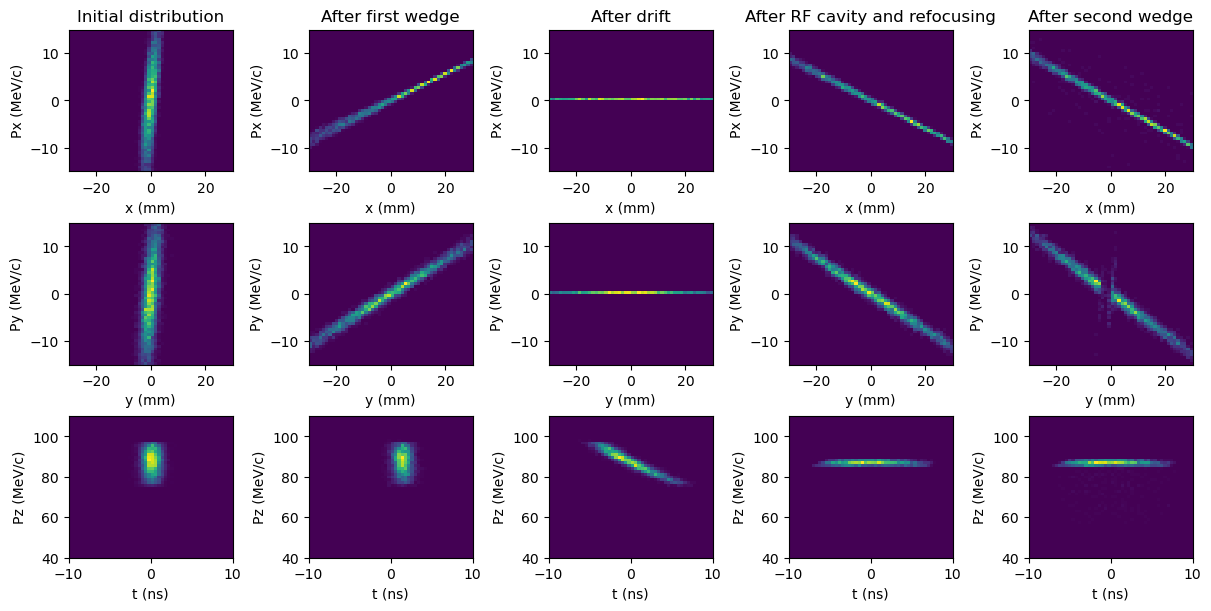

In [124]:
# a more reasonable size
PLOT_TARGETS = [post_w1, df_opt_q, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-30, 30], [-15, 15]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(12, 6)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4